# Analyzing the prediction intervals created

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotnine import *
from pyhere import here
import itertools
import seaborn as sns

In [2]:
phot = pd.read_csv(here('data/cleaned', 'MIRION_cleaned_everything.csv'))

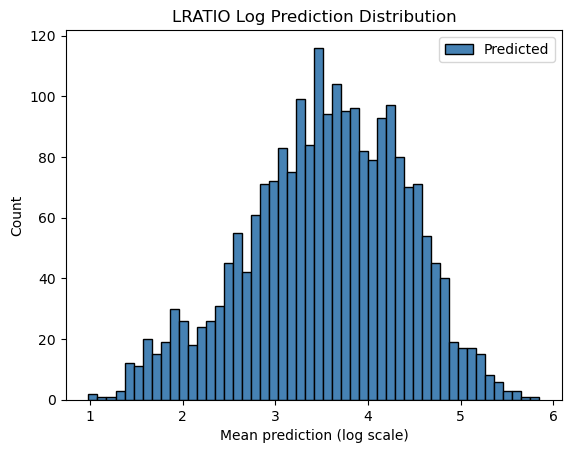

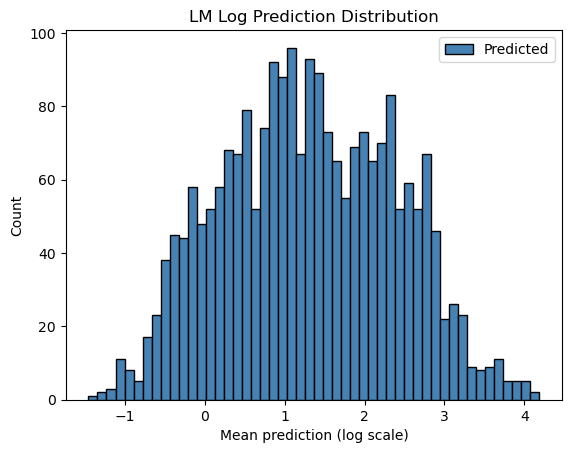

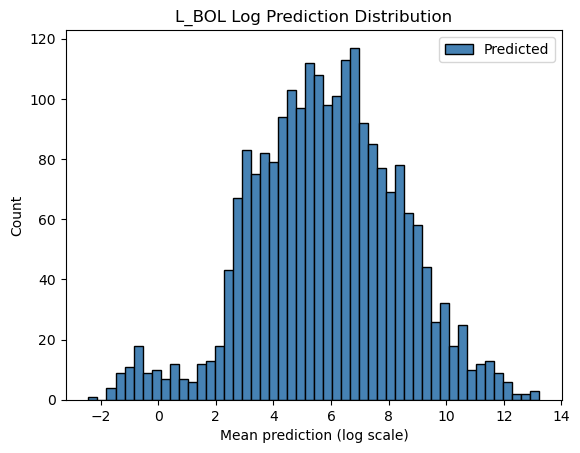

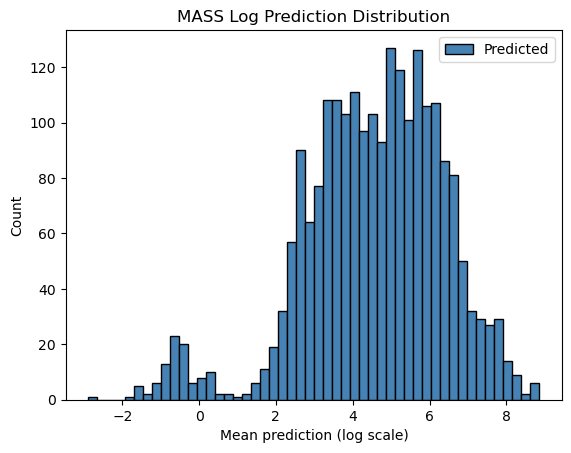

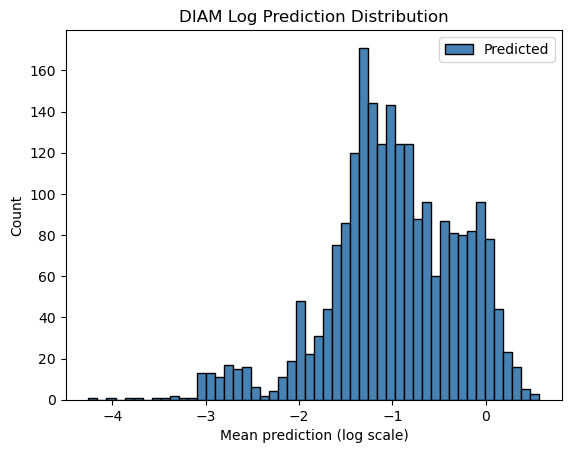

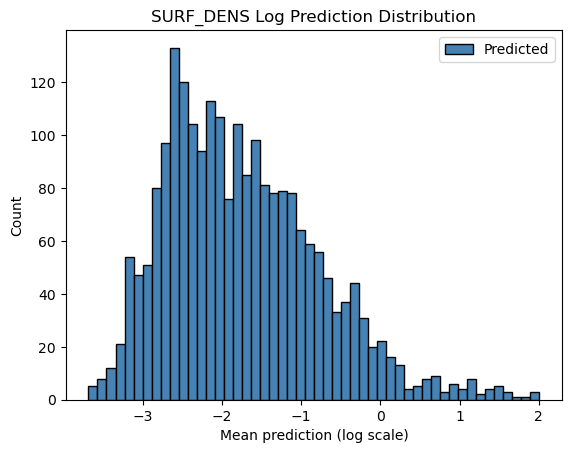

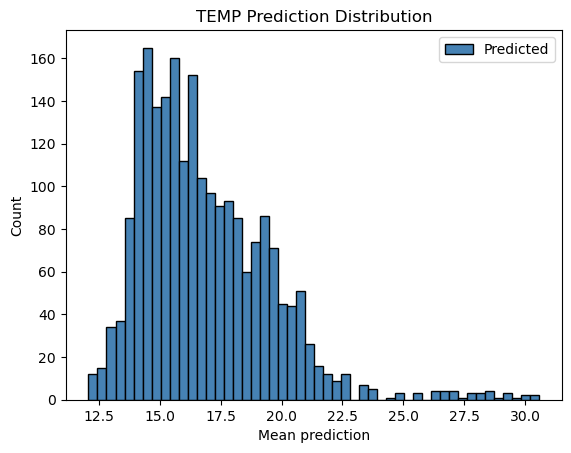

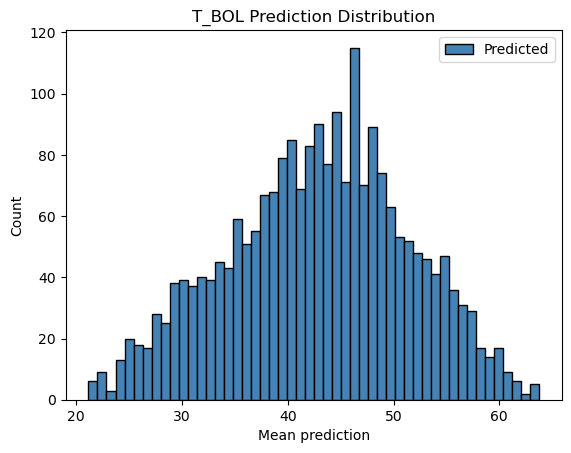

In [18]:
for response in ["LRATIO", "LM", "L_BOL", "MASS", "DIAM", "SURF_DENS", "TEMP", "T_BOL"]:
    data = pd.read_csv(here('predictions', f'{response}_final_predictions.csv'))

    if response == 'TEMP' or response == 'T_BOL':
        pred_data = data['mean_pred']
    else:
        pred_data = np.log(data['mean_pred'])

    plt.hist(pred_data, bins=50, color='steelblue', edgecolor='black', label='Predicted')

    if response == 'TEMP' or response == 'T_BOL':
        plt.title(f'{response} Prediction Distribution')
        plt.xlabel('Mean prediction')
    else:
        plt.title(f'{response} Log Prediction Distribution')
        plt.xlabel('Mean prediction (log scale)')
    plt.ylabel('Count')

    plt.legend()
    plt.show()

## Comparing these predicted yellowballs to those in the actual MIRION catalog

Note: these are not the sample yellowballs being compared. They are not the predicted values of each yellowball vs their own true calculated values. They are the predictions for the ones we don't know, and the true values for the ones that we do. It is still useful to visualize these differences though, potentially.

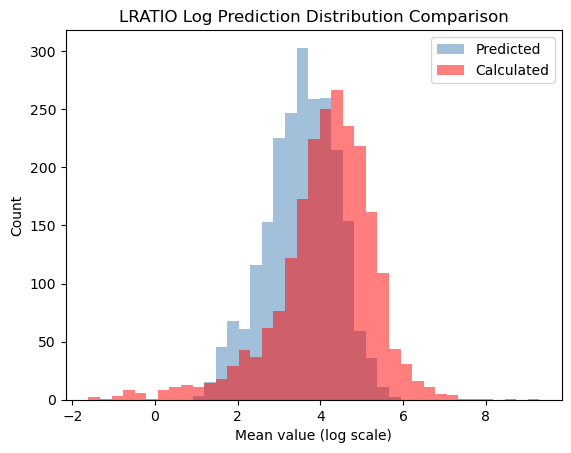

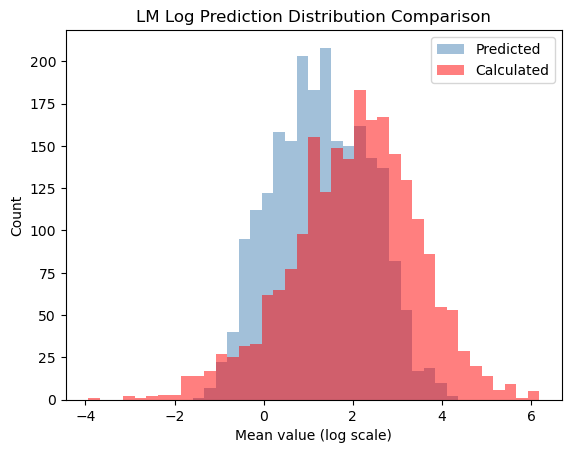

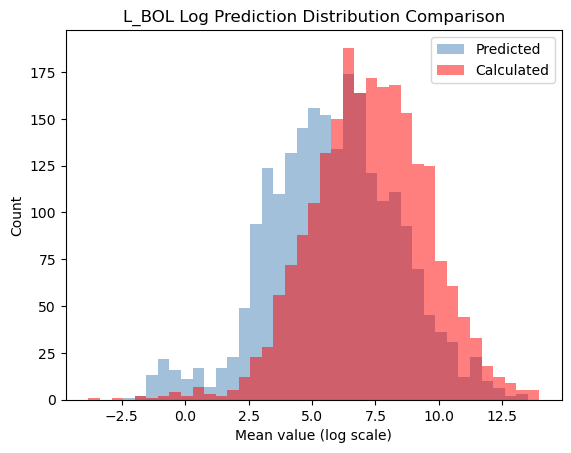

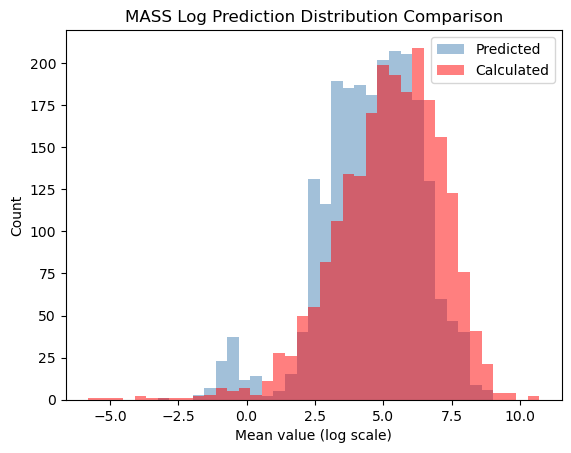

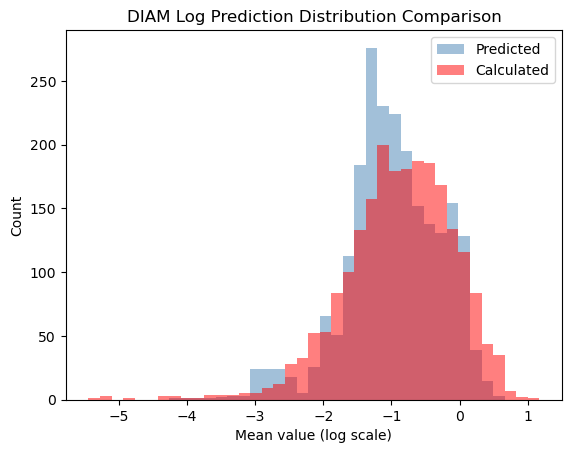

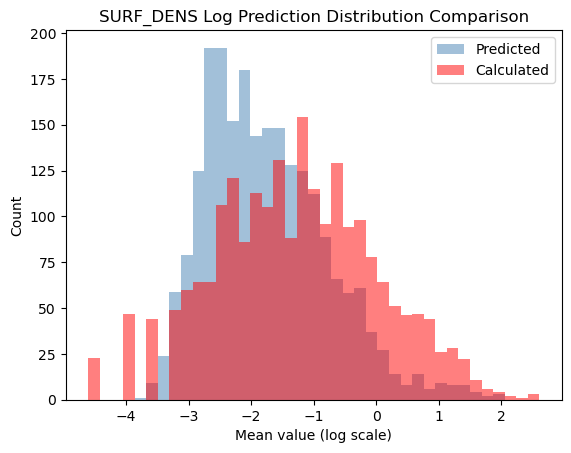

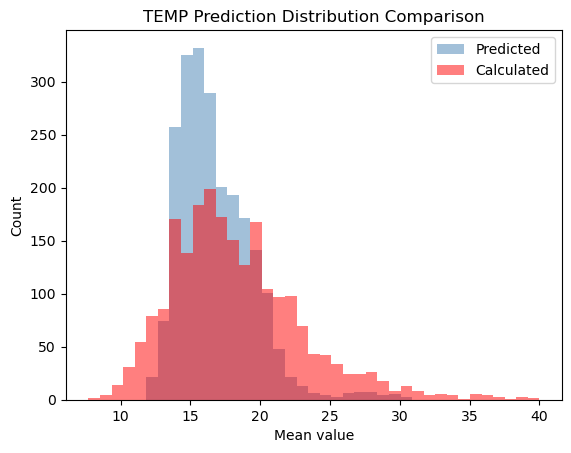

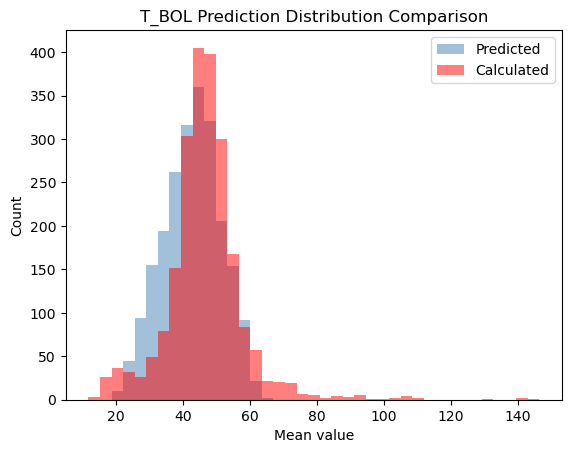

In [ ]:
for response in ["LRATIO", "LM", "L_BOL", "MASS", "DIAM", "SURF_DENS", "TEMP", "T_BOL"]:
    data = pd.read_csv(here('predictions', f'{response}_final_predictions.csv'))

    if response == 'TEMP' or response == 'T_BOL':
        pred_data = data['mean_pred']
        phot_data = phot[response]
    else:
        pred_data = np.log(data['mean_pred'])
        phot_data = np.log(phot[response])

    phot_data_sample = phot_data.sample(n=2220)

    combined_data = np.hstack((pred_data, phot_data_sample))
    bins = np.linspace(min(combined_data), max(combined_data), 40)

    plt.hist(pred_data, bins=bins, color='steelblue', alpha=0.5, label='Predicted')
    plt.hist(phot_data_sample, bins=bins, color='red', alpha=0.5, label='Calculated')

    if response == 'TEMP' or response == 'T_BOL':
        plt.title(f'{response} Prediction Distribution Comparison')
        plt.xlabel('Mean value')
    else:
        plt.title(f'{response} Log Prediction Distribution Comparison')
        plt.xlabel('Mean value (log scale)')
    plt.ylabel('Count')

    plt.legend()
    plt.show()